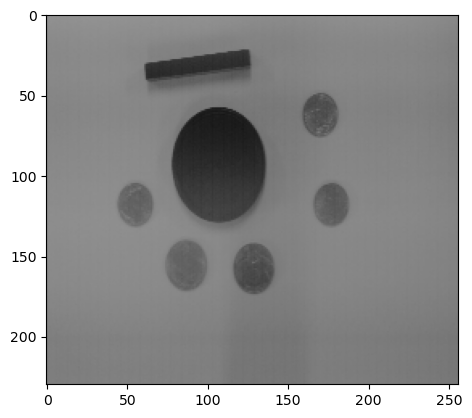

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

image = cv2.imread("images/MORPHO.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

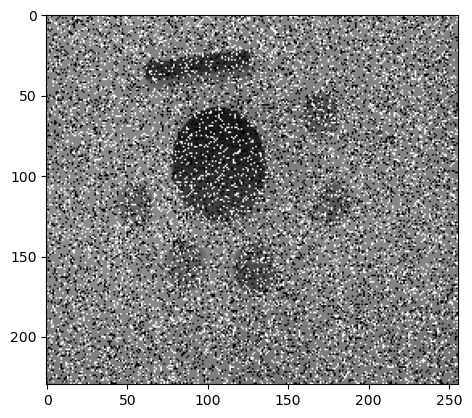

In [11]:
#Perturbe (ensucie) la imagen con 25% de ruido “sal y pimienta”. 
from skimage.util import random_noise

noised_image = random_noise(image, mode='s&p', amount=0.25)

# Visualizar imagen
plt.imshow(noised_image, cmap="gray")
plt.show()

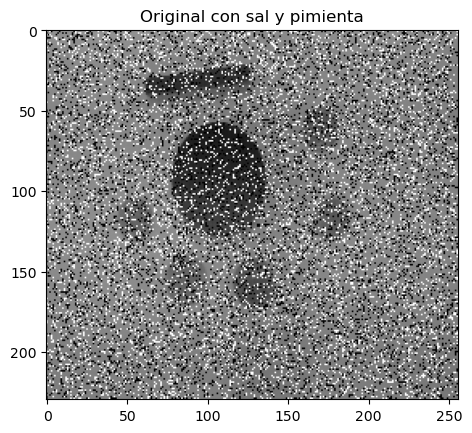

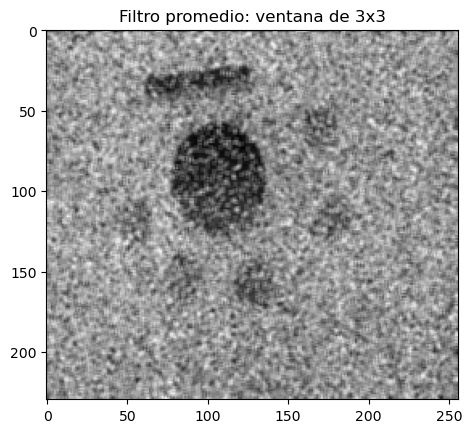

In [12]:
# Aplique un filtro promedio 3x3 sobre la imagen con ruido
from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean

avg = mean(noised_image, footprint_rectangle((3,3)))

# Visualizar imagen
plt.imshow(noised_image, cmap="gray")
plt.title("Original con sal y pimienta")
plt.show()

# Visualizar imagen
plt.imshow(avg, cmap="gray")
plt.title("Filtro promedio: ventana de 3x3")
plt.show()

Visualmente, ¿cómo es el resultado y a qué se debe?

El resultado es malo, la termina de empeorar, esto se debe a que el filtro promedio actua mejor en imagenes con ruido gaussiano o Erlang, pero con sal y pimienta no.

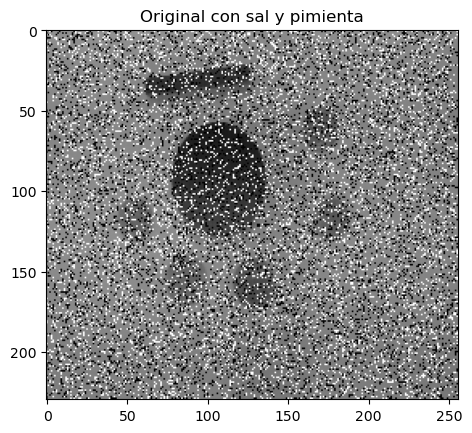

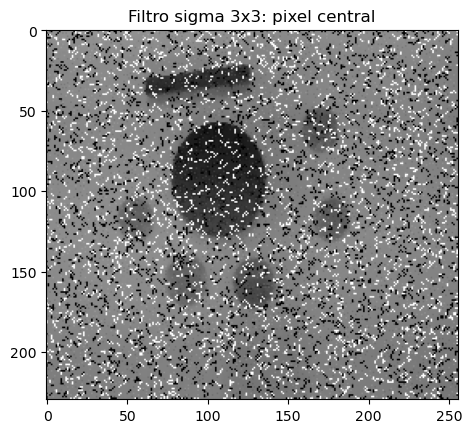

In [13]:
#Aplique un filtro sigma 3x3 calculando el valor medio a partir pixel central sobre la imagen con ruido

import numpy as np
from scipy.ndimage import generic_filter


def sigma_filter(values, median=False):
    
    mean = values[int((values.size)//2)]
    if median:
      mean = np.median(values)

    std = np.std(values)
    filtered_values = values[(values > mean - std) & (values < mean + std)]
    return np.mean(values) if filtered_values.size<=1 else np.mean(filtered_values)


filtered_image = generic_filter(noised_image, sigma_filter, size=(3,3))

# Visualizar imagen
plt.imshow(noised_image, cmap="gray")
plt.title("Original con sal y pimienta")
plt.show()

# Visualizar imagen
plt.imshow(filtered_image, cmap="gray")
plt.title("Filtro sigma 3x3: pixel central")
plt.show()

Visualmente, ¿cómo es el resultado comparado con el filtro promedio lineal? Consultando la definición del Sigma explique este resultado. En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios puntos aberrantes. ¿A qué se debe esto?

Comparado al filtro promedio, este filtro sigma, reduce el ruido sal y pimienta mucho mejor. El filtro sigma mejora la imagen porque utiliza la desviación estándar como criterio estadístico para excluir valores dentro del vecindario en base al pixen central. Esto permite reducir el ruido sin promediar indiscriminadamente todos los píxeles, preservando mejor los bordes en comparación con el filtro promedio tradicional.

Sin embargo, en presencia de ruido sal y pimienta, pueden permanecer puntos aberrantes debido a que este tipo de ruido introduce valores extremos que alteran la desviación estándar del vecindario. Además, si el píxel central está afectado por el ruido, el filtro lo usa como referencia para calcular el rango de la desviacion, y esto nos afecta el resultado.

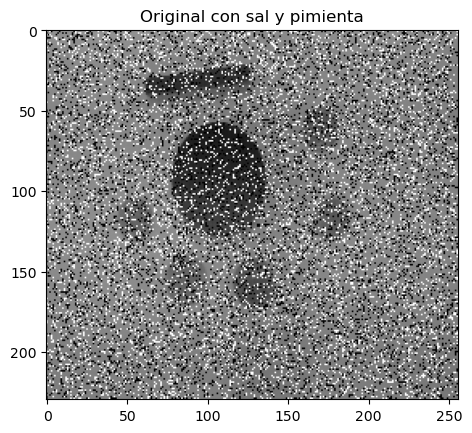

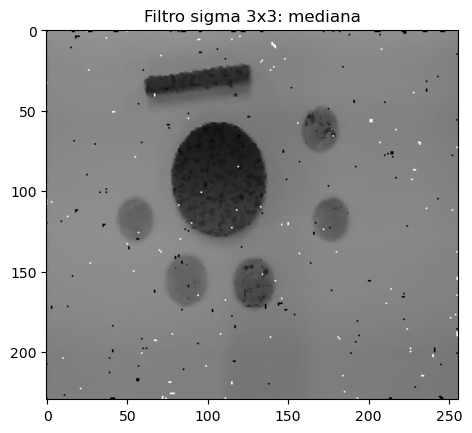

In [14]:
#Aplique un filtro sigma 3x3 calculando el valor medio a partir de la mediana de los pixeles del vecindario sobre la imagen con ruido.

import numpy as np
from scipy.ndimage import generic_filter


def sigma_filter(values, median=False):
    
    mean = values[int((values.size)//2)]
    if median:
      mean = np.median(values)

    std = np.std(values)
    filtered_values = values[(values > mean - std) & (values < mean + std)]
    return np.mean(values) if filtered_values.size<=1 else np.mean(filtered_values)


filtered_image = generic_filter(
    noised_image,
    sigma_filter,
    size=(3, 3),
    extra_arguments=(True,)
)

# Visualizar imagen
plt.imshow(noised_image, cmap="gray")
plt.title("Original con sal y pimienta")
plt.show()

# Visualizar imagen
plt.imshow(filtered_image, cmap="gray")
plt.title("Filtro sigma 3x3: mediana")
plt.show()

Visualmente, ¿cómo es el resultado comparado con el filtro promedio lineal? Consultando la definición del Sigma explique este resultado. En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios sólo algunos aberrantes. ¿A qué se debe esto? ¿Por qué hay una diferencia significativa con el resultado anterior?

Comparado al filtro promedio, este filtro sigma, reduce el ruido sal y pimienta mucho mejor. El filtro sigma mejora la imagen porque utiliza la desviación estándar como criterio estadístico para excluir valores dentro del vecindario en base a la mediana. Esto permite reducir el ruido sin promediar indiscriminadamente todos los píxeles, preservando mejor los bordes en comparación con el filtro promedio tradicional.

Sin embargo, en presencia de ruido sal y pimienta, pueden permanecer puntos aberrantes debido a que este tipo de ruido introduce valores extremos que alteran la desviación estándar del vecindario. Además, si el píxel central está afectado por el ruido, el filtro lo usa como referencia para calcular el rango de la desviacion, y esto nos afecta el resultado.


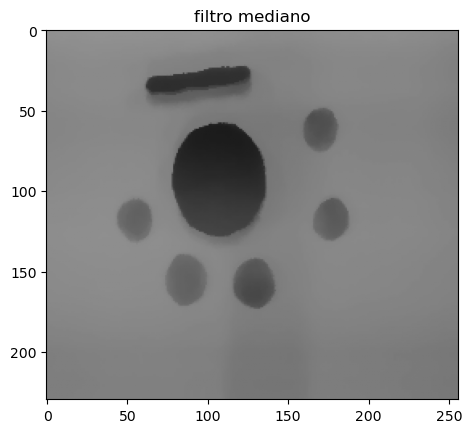

In [15]:
#Aplique un filtro mediano 3x3 a la imagen con ruido
from skimage import data
from skimage.morphology import disk, ball
from skimage.filters.rank import median
import numpy as np

rng = np.random.default_rng()

volume = rng.integers(0, 255, size=(10,10,10), dtype=np.uint8)
med = median(noised_image, disk(5))
med_vol = median(volume, ball(5))

# Visualizar imagen
plt.imshow(med, cmap="gray", vmin=0, vmax=255)
plt.title("filtro mediano")
plt.show()


Visualmente, ¿cómo es el resultado comparado con los dos filtros anteriores? ¿A qué se debe este resultado? Evalúe los otros filtros que ofrece el módulo filters.rank de scikit-image: majority, maximum, minumum, modal, geometric_mean. Explique su comportamiento.

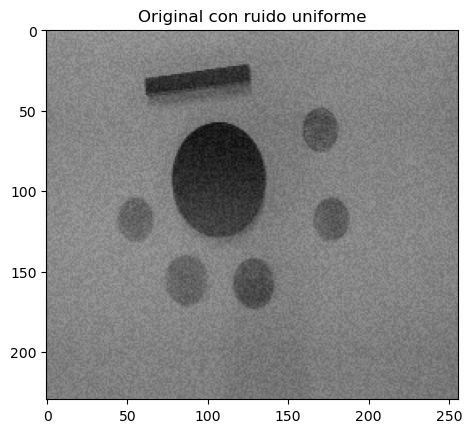

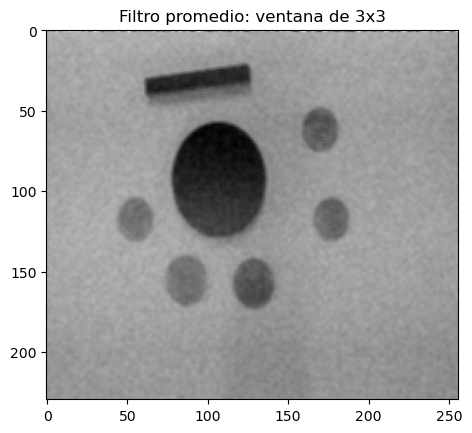

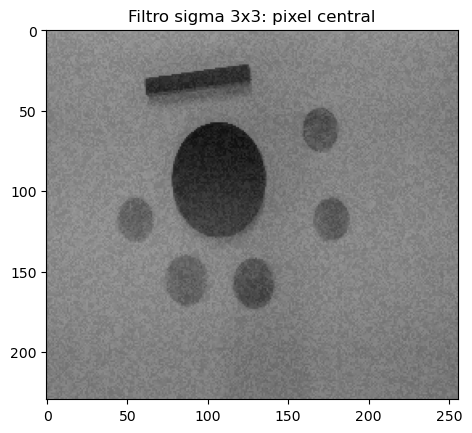

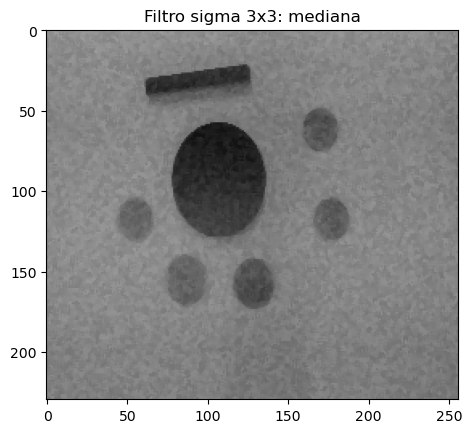

In [16]:
#Repita las operaciones 3 a 6, pero con un ruido uniforme de amplitud 30.

# Se le aplica ruido uniforme
noise = np.random.uniform(low=-15, high=15, size=image.shape)
noised_image = image + noise
noised_image = noised_image.astype(np.uint8)

# Visualizar imagen
plt.imshow(noised_image, cmap="gray")
plt.title("Original con ruido uniforme")
plt.show()

# ------ Aplicar filtro promedio 3x3 ------
avg = mean(noised_image, footprint_rectangle((3,3)))

# Visualizar imagen
plt.imshow(avg, cmap="gray")
plt.title("Filtro promedio: ventana de 3x3")
plt.show()

# ------- Aplicar filtro sigma 3x3 PIXEL CENTRAL-------
filtered_image = generic_filter(noised_image, sigma_filter, size=(3,3))
# Visualizar imagen
plt.imshow(filtered_image, cmap="gray")
plt.title("Filtro sigma 3x3: pixel central")
plt.show()

# ------- Aplicar filtro sigma 3x3 MEDIANA-------
filtered_image = generic_filter(
    noised_image,
    sigma_filter,
    size=(3, 3),
    extra_arguments=(True,)
)
# Visualizar imagen
plt.imshow(filtered_image, cmap="gray")
plt.title("Filtro sigma 3x3: mediana")
plt.show()

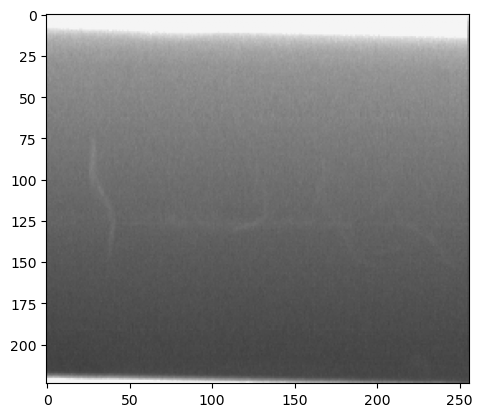

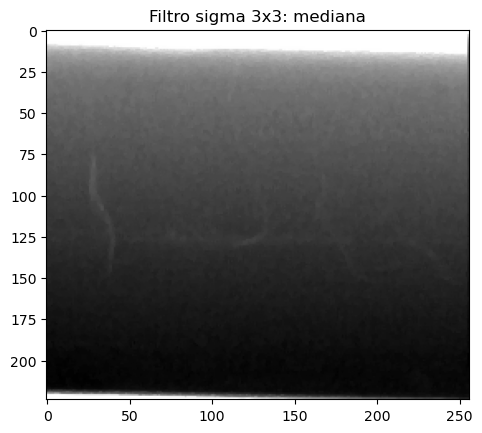

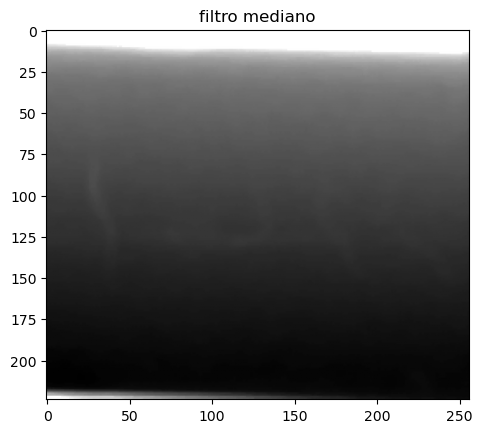

In [17]:
#Repita el punto 6 y 7 con la imagen fissure.png.
image = cv2.imread("images/fissure.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# ------- Aplicar filtro sigma 3x3 MEDIANA-------
filtered_image = generic_filter(
    image,
    sigma_filter,
    size=(3, 3),
    extra_arguments=(True,)
)
# Visualizar imagen
plt.imshow(filtered_image, cmap="gray")
plt.title("Filtro sigma 3x3: mediana")
plt.show()

# ------ Aplicar filtro mediano ---------
rng = np.random.default_rng()

volume = rng.integers(0, 255, size=(10,10,10), dtype=np.uint8)
med = median(image, disk(5))
med_vol = median(volume, ball(5))

# Visualizar imagen
plt.imshow(med, cmap="gray")
plt.title("filtro mediano")
plt.show()


Compare los resultados obtenidos. Concluya en qué casos (características de la imagen, tipo de ruido, ...) se usan cada uno de estos filtros.

En esta imagen el filtro no produjo un cambio significativo porque la imagen presenta un gradiente suave sin ruido. El filtro mediana es especialmente efectivo eliminando ruido sal y pimienta, pero en regiones de variación continua su efecto es mínimo, ya que la mediana del vecindario tiende a coincidir con el valor original del píxel.